In [1]:
import sys
sys.path.append('../')
from utils_models import *


In [36]:
amp_with_2pi = 0.07398497870264828
flux = 0.40236976700920757
pulse_length = 61.828771095268166

t_rise = 20
t_with_edges = t_rise + pulse_length
t_with_edges

81.82877109526817

In [37]:
tlist = np.linspace(0,t_with_edges,int(t_with_edges))

In [38]:
fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
tune_tmon = scqubits.TunableTransmon(
    EJmax=50,
    EC=0.5,
    d=0.01,
    flux=flux,
    ng=0.0,
    ncut=30,
    truncated_dim = 4
    )
system = FluxoniumTunableTransmonSystem(
    fluxonium  = fluxonium,
    tune_tmon = tune_tmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    )


In [39]:

w_d = system.evals[system.product_to_dressed[(0,1)]] - system.evals[system.product_to_dressed[(0,0)]]
w_d

7.223016852958707

In [40]:
results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.tune_tmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d': w_d,
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': t_rise,
                    't_square': pulse_length - t_rise
                })],
        c_ops = None,
        e_ops = [system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i,1)])))  for i in range(3)]
    )


 Total run time:  12.60s*] Elapsed 12.60s / Remaining 00:00:00:00
 Total run time:  12.74s*] Elapsed 12.74s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 81/81 [00:00<00:00, 6433.59it/s]


 Total run time:  13.98s*] Elapsed 13.98s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 81/81 [00:00<00:00, 6631.63it/s]


(0.0, 0.02)

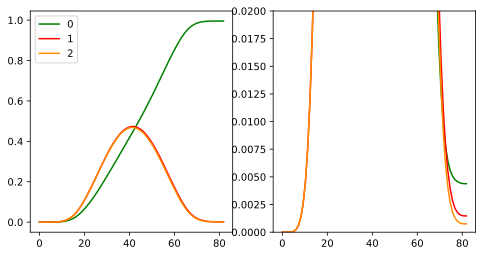

In [41]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(1,2,figsize = (8,4))
for i in range(3):
    axes[0].plot(tlist,results[i].expect[i],label = f"{i}",color = colors[i])
    
    axes[1].plot(tlist,results[i].expect[i] if i != 0 else 1- results[i].expect[i],label = f"{i}",color = colors[i])

axes[0].legend()
axes[1].set_ylim(0,0.02)